##**Project 1: Student Performance Predictor**
## **Task 1: Load and Explore the Data**

First 5 Rows:
   Hours  Score
0      1     35
1      2     45
2      3     48
3      4     52
4      5     60

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Hours   10 non-null     int64
 1   Score   10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes
None

Missing Values:
Hours    0
Score    0
dtype: int64

Statistics:
          Hours      Score
count  10.00000  10.000000
mean    5.50000  64.800000
std     3.02765  20.026649
min     1.00000  35.000000
25%     3.25000  49.000000
50%     5.50000  64.000000
75%     7.75000  80.250000
max    10.00000  95.000000


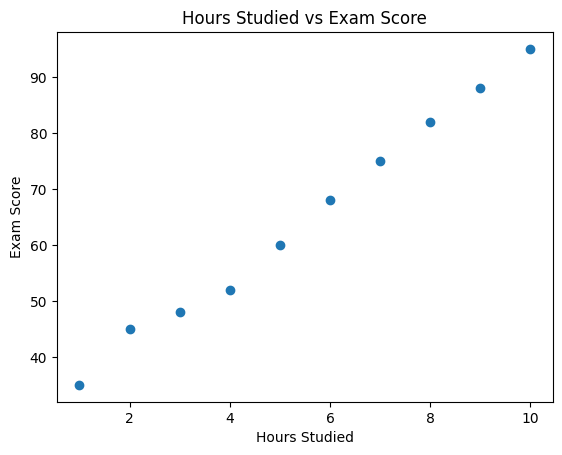

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Create Dataset
data = {
    'Hours': [1,2,3,4,5,6,7,8,9,10],
    'Score': [35,45,48,52,60,68,75,82,88,95]
}

df = pd.DataFrame(data)

# First 5 Rows
print("First 5 Rows:")
print(df.head())

# Dataset Info
print("\nDataset Info:")
print(df.info())

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Statistics
print("\nStatistics:")
print(df.describe())

# Visualization
plt.scatter(df['Hours'], df['Score'])
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studied vs Exam Score')
plt.show()

## **Task 2: Train a Linear Regression Model**

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features and Target
X = df[['Hours']]
y = df['Score']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Model
model = LinearRegression()

# Train Model
model.fit(X_train, y_train)

# Display Results
print(f"Slope (coefficient): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

Slope (coefficient): 6.78
Intercept: 27.06


## **Task 3: Evaluate and Make Predictions**

In [3]:
from sklearn.metrics import mean_absolute_error
import pandas as pd

# Predict on test data
y_pred = model.predict(X_test)

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} points")

# Compare Actual vs Predicted
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print("\nActual vs Predicted:")
print(results)

# Predict score for a new student

new_hours = pd.DataFrame({'Hours': [4.5]})
predicted_score = model.predict(new_hours)

print(f"\nPredicted score for 4.5 hours: {predicted_score[0]:.2f}")

Mean Absolute Error: 2.25 points

Actual vs Predicted:
   Actual  Predicted
8      88   88.12069
1      45   40.62931

Predicted score for 4.5 hours: 57.59


##Project 2: Flower Classifier
##Task 4: Prepare the Data (Split into Train/Test)

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
# Load dataset
iris = load_iris()
# Features and labels
X = iris.data
y = iris.target
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.3,
random_state=1
)
# Print sizes
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 105
Test samples: 45


##**Task 5: Train a k-Nearest Neighbors (k-NN) Classifier**

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Load dataset
iris = load_iris()

# Features and target
X = iris.data
y = iris.target

# Split data (same as Task 4)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=1
)

# Create k-NN model (k = 3)
knn = KNeighborsClassifier(n_neighbors=3)

# Train model
knn.fit(X_train, y_train)

# Predict on test data
y_pred = knn.predict(X_test)

# Accuracy
accuracy = knn.score(X_test, y_test)
print(f"Test accuracy: {accuracy * 100:.2f}%")

# Show some predictions vs actual
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nSample Results:")
print(results.head())


Test accuracy: 97.78%

Sample Results:
   Actual  Predicted
0       0          0
1       1          1
2       1          1
3       0          0
4       2          2


## **Task 6: Improve the Model with Feature Scaling and Evaluation**

In [6]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Scaling
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Train k-NN on scaled data
knn_scaled = KNeighborsClassifier(n_neighbors=3)
knn_scaled.fit(X_train_scaled, y_train)

# Step 3: Prediction
y_pred_scaled = knn_scaled.predict(X_test_scaled)

# Step 4: Accuracy
accuracy = knn_scaled.score(X_test_scaled, y_test)
print(f"Scaled Test Accuracy: {accuracy * 100:.2f}%")

# Step 5: Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_scaled,
target_names=iris.target_names))

# Step 6: Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_scaled))

Scaled Test Accuracy: 97.78%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       0.95      1.00      0.97        18
   virginica       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.98        45
weighted avg       0.98      0.98      0.98        45


Confusion Matrix:
[[14  0  0]
 [ 0 18  0]
 [ 0  1 12]]
